In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
with open('names.txt') as f:
    words = f.read().split()
len(words)

32033

In [3]:
vocabs = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(vocabs)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(stoi)
print(itos)
print(vocab_size)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [50]:
# Create Data sets: Train, Dev, Test
block_size = 8
def build_dataset(words):
    X = []
    Y = []
    for word in words:
        context = [0]*block_size
        word = word + '.'
        for char in word:
            ix = stoi[char]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(f'X shape: {X.shape}, Y shape: {Y.shape}')
    return X,Y

import random
random.seed(42)
random.shuffle(words)

Xtr, Ytr = build_dataset(words[0: int(0.8*len(words))])
Xdev, Ydev = build_dataset(words[int(0.8*len(words)): int(0.9*len(words))])
Xtst, Ytst = build_dataset(words[int(0.9*len(words)):])

X shape: torch.Size([182580, 8]), Y shape: torch.Size([182580])
X shape: torch.Size([22767, 8]), Y shape: torch.Size([22767])
X shape: torch.Size([22799, 8]), Y shape: torch.Size([22799])


In [83]:
# Creat Classes
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn(fan_in, fan_out) / fan_in**0.5
        self.bias = torch.randn(fan_out) if bias else None
        
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        p = [self.weight] + ([] if self.bias is None else [self.bias])
        return p
    
class BatchNorm1d:
    
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.training = True
        self.eps = eps
        self.momentum = momentum 
        # parameters
        self.beta = torch.zeros(dim)
        self.gama = torch.ones(dim)
        # buffers
        self.running_var = torch.ones(dim)
        self.running_mean = torch.zeros(dim)
        
    def __call__(self, x):   
        if self.training:
            if x.ndim == 2:     # Before WaveNet and moving to FlattenConsecutive: the dim of x was 2; but after that
                dim = 0         # we might pass x as 3-dim vector and by using previous setting(not having if&elif)
            elif x.ndim == 3:   # it gets mean and variance on first dim. which is not true the mean of channels should 
                dim = (0,1)     # be calculated on two first dim. 
            xmean = x.mean(dim, keepdim = True)
            xvar = x.var(dim, keepdim = True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        
        xhat = (x-xmean)/torch.sqrt(xvar+self.eps)
        self.out = self.gama * xhat + self.beta
        
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.beta, self.gama]
    

        
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []
    

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.emb = torch.randn(num_embeddings, embedding_dim)
        
    def __call__(self, x):
        self.out = self.emb[x]
        return self.out
    
    def parameters(self):
        return [self.emb]

class FlattenConsecutive:
    def __init__(self, n):  # define for the porpus of wavenet
        self.n = n  # define how many consequative chars should be concat together 
    
    def __call__(self, x):
        #x.view(x.shape[0], -1)  before changing to wavenet
        
        B,T,C = x.shape  # define num of samples(batch), num of chars in each sample(Time), embed size of chars(channels) 
        x = x.view(B, T//self.n, self.n*C) # reshape x for each sample to => have T//n set of chars (vectors) 
                                            # with length of n*C; instead of concat all chars of a sample to a single
                                            # vector of size T*C. To avoid concat all info simultaniously in on step
                                            # and concat info gradually. 
        if T//self.n == 1:
            x = torch.squeeze(x, dim = 1) # for the case that T == n and avoid creating (B,1,n*c) tensor. we want (B, n*c) like before
        
        self.out = x
        return self.out
    
    def parameters(self):
        return []
    
    
class Sequential:
    def __init__(self, layers):
        self.layers = layers
        
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
            
        

In [84]:
torch.manual_seed(42); # seed rng for reproducibility

In [85]:
n_emb = 24
n_hidden = 128
n_block = block_size
n_vocab = vocab_size

# C = torch.randn(n_vocab, n_emb) # before having the Embedding class
# Layers = [Embedding(n_vocab, n_emb), Flatten(),
#           Linear(n_block*n_emb, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#           Linear(n_hidden, n_vocab)
#         ]

# Before WaveNet and moving to FlattenConsecutive:
# model = Sequential([Embedding(n_vocab, n_emb), Flatten(), 
#                     Linear(n_block*n_emb, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(),
#                     Linear(n_hidden, n_vocab)
#                     ])

model = Sequential([Embedding(n_vocab, n_emb),  #(32, 8, 10)
                    FlattenConsecutive(2), Linear(2*n_emb, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(), #(32,4,20)@(20,68) = (32,4,68)
                    FlattenConsecutive(2), Linear(2*n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(), # (32, 2, 136)@(136,68) = (32,2,68)
                    FlattenConsecutive(2), Linear(2*n_hidden, n_hidden, bias = False), BatchNorm1d(n_hidden), Tanh(), # (32, 136)@(136,68) = (32,68)
                    Linear(n_hidden, n_vocab)
                    ])


with torch.no_grad():
    model.layers[-1].weight *= 0.1

# for layer in Layer[:, -1]:
#     if isinstance(layer, Linear):
#         layer.weights *= 1         # this part is not required due to having batchnorm layer


    
# params =  [p for layer in Layers for p in layer.parameters()] befor the sequential class # + [C] # before having the Embedding class 
params = model.parameters()
print(sum(p.nelement() for p in params))        
for p in params:
    p.requires_grad = True    

76579


In [87]:
batch_size = 32
iteration = 200000
lossi = []

for i in range(iteration):
    bi = torch.randint(Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[bi], Ytr[bi]
    
    #emb = C[Xb]
    #x = emb.view(-1, n_block * n_emb)  # before having the Embedding class and the Flatten class 
    
    #x = Xb
    #for layer in Layers:  # before having the Sequential class
    #    x = layer(x)
    
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  
    
    # backward
    for p in params:
        p.grad = None
        
    loss.backward()
    
    
    # updating
    lr = 0.1 if i < 100000 else 0.01
    for p in params:
        p.data += -lr * p.grad
    if i % 10000 == 0:
        print(f"{i}/{iteration}: {loss.item():.4f}")
    # tracking
    lossi.append(loss.log10().item())

0/200000: 4.0509
10000/200000: 1.9581
20000/200000: 1.8491
30000/200000: 2.2173
40000/200000: 2.3081
50000/200000: 2.3922
60000/200000: 1.7724
70000/200000: 1.9884
80000/200000: 1.8763
90000/200000: 1.5695
100000/200000: 1.5523
110000/200000: 1.9374
120000/200000: 1.6974
130000/200000: 1.8576
140000/200000: 2.1947
150000/200000: 1.9541
160000/200000: 1.6203
170000/200000: 2.1268
180000/200000: 1.4368
190000/200000: 1.7511


In [88]:
# layer inspector
for layer in model.layers:
    print(layer.__class__.__name__, layer.out.shape)

Embedding torch.Size([32, 8, 24])
FlattenConsecutive torch.Size([32, 4, 48])
Linear torch.Size([32, 4, 128])
BatchNorm1d torch.Size([32, 4, 128])
Tanh torch.Size([32, 4, 128])
FlattenConsecutive torch.Size([32, 2, 256])
Linear torch.Size([32, 2, 128])
BatchNorm1d torch.Size([32, 2, 128])
Tanh torch.Size([32, 2, 128])
FlattenConsecutive torch.Size([32, 256])
Linear torch.Size([32, 128])
BatchNorm1d torch.Size([32, 128])
Tanh torch.Size([32, 128])
Linear torch.Size([32, 27])


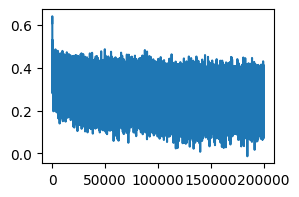

In [89]:
plt.figure(figsize = (3,2))
plt.plot(lossi)
plt.show()

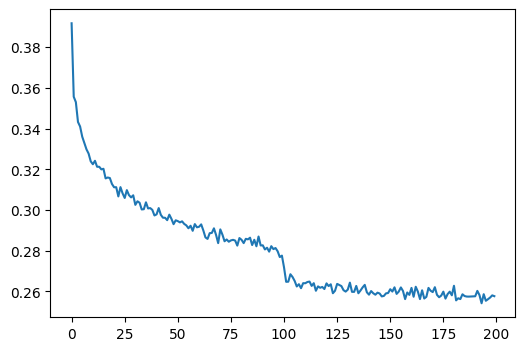

In [90]:
plt.figure(figsize = (6,4))
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))  # reshape the losses and get mean of losses for each 1000 iteration
plt.show()

In [91]:
for layer in model.layers:  # Layers was for before having the Sequential Class
    layer.training = False

In [92]:
@torch.no_grad()
def split_loss(split):
    splits = {'train':(Xtr,Ytr),
              'dev' :(Xdev, Ydev),
              'test' :(Xtst, Ytst)
             }
    x, y = splits[split]
    #emb = C[x]
    ##embcat = emb.view(emb.shape[0], -1)
    #embcat = emb.view(-1, n_block*n_emb)  # before having the Embedding class and the Flatten class
    
    #for layer in Layers:
    #    x = layer(x)         #before having the Sequential Class
    
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(f'{split} loss: {loss.item()}')
    
split_loss('train')
split_loss('dev')

train loss: 1.7845807075500488
dev loss: 1.9905349016189575


In [93]:
# Sample from the model

for _ in range(20):
    out = []
    context = [0] * n_block
    while True:
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, 1)
        ix = torch.multinomial(probs, num_samples = 1).item()
        if ix:
            out.append(itos[ix])
            context = context[1:] + [ix]
        else: break
    print(''.join(out))   
    

kaylen
mccall
zailor
dalynn
rosefan
denica
myneas
dacphos
petrik
isabella
jayson
layaie
manson
ayen
edustin
rohan
jafton
anabella
harlee
mangson
